In [28]:
import datetime

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cmocean
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gp
import regionmask

## Read metric data

Example data from `/datasets/work/af-ag2050-climate/reference/ag2050_extension_metrics_outputs/100_2025-may_cdx_cs_a-e5_h_ccam-2203_q-agcd/annRain.csv`:
- GCM: ACCESS-ESM1-5
- RCM: CCAM-v2203-SN
- Experiment: ssp126
- Bias correction method: MRNBC
- Bias correction reference: AGCD	

In [4]:
df = pd.read_csv('annRain.csv')

In [5]:
df

,date,out,latitude,longitude
0,1960,1436.4,86,629
1,1961,867.9,86,629
2,1962,1410.2,86,629
3,1963,967.8,86,629
4,1964,795.0,86,629
...,...,...,...,...
15295605,2010,729.3,251,752
15295606,2011,623.8,251,752
15295607,2012,652.6,251,752
15295608,2013,1076.0,251,752


In [6]:
df_indexed = df.set_index(['latitude', 'longitude'])

In [7]:
da_list = []
for year in df['date'].unique():
    df_year = df_indexed[df_indexed['date'] == year]
    da_year = df_year['out'].to_xarray()
    da_year['time'] = datetime.datetime(year, 7, 1)
    da_list.append(da_year)

In [3]:
def lat_index_to_value(lat_index):
    """Convert latitude index to value"""

    lat_values = np.round(np.arange(-10, -44.51, -0.05), 2)
    lat_value = lat_values[lat_index]

    return lat_value


def lon_index_to_value(lon_index):
    """Convert latitude index to value"""

    lon_values = np.round(np.arange(112, 156.26, 0.05), 2)
    lon_value = lon_values[lon_index]

    return lon_value


v_lat_index_to_value = np.vectorize(lat_index_to_value)
v_lon_index_to_value = np.vectorize(lon_index_to_value)

In [10]:
da = xr.concat(da_list, dim='time')
da['latitude'] = v_lat_index_to_value(da['latitude'])
da['longitude'] = v_lon_index_to_value(da['longitude'])

In [34]:
da = da.rename({'latitude': 'lat', 'longitude': 'lon'})

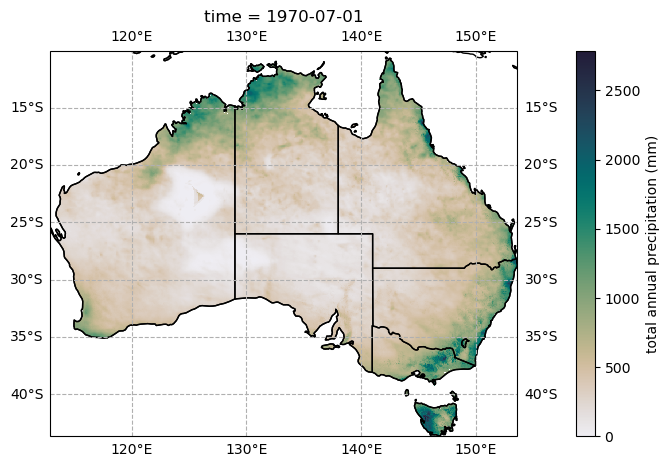

In [16]:
fig = plt.figure(figsize=[15, 5])
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    
da.isel(time=10).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    cbar_kwargs={'label': 'total annual precipitation (mm)'},
)
ax.coastlines()
ax.add_feature(cartopy.feature.STATES)
ax.gridlines(linestyle="--", draw_labels=True)
    
plt.show()

## Read shapefile

Downloaded from: https://www.agriculture.gov.au/abares/research-topics/surveys/farm-survey-data

In [18]:
broadacre_gdf = gp.read_file('aagis_asgs16v1_g5a.shp_/aagis_asgs16v1_g5a.shp')

In [19]:
broadacre_gdf

,aagis,class,name,zone,geometry
0,111,111,NSW Far West,Pastoral,"POLYGON ((146.37539 -28.99878, 146.94501 -28.9..."
1,121,121,NSW North West Slopes and Plains,Wheat Sheep,"POLYGON ((150.29716 -28.54252, 150.29783 -28.5..."
2,122,122,NSW Central West,Wheat Sheep,"POLYGON ((149.02819 -30.6089, 149.05246 -30.63..."
3,123,123,NSW Riverina,Wheat Sheep,"POLYGON ((145.34428 -32.68249, 145.33056 -32.7..."
4,131,131,NSW Tablelands (Northern Central and Southern),High Rainfall,"POLYGON ((152.51672 -28.25466, 152.5161 -28.25..."
5,132,132,NSW Coastal,High Rainfall,"MULTIPOLYGON (((150.05118 -37.26355, 150.05099..."
6,221,221,VIC Mallee,Wheat Sheep,"POLYGON ((140.96768 -33.98983, 140.96827 -33.9..."
7,222,222,VIC Wimmera,Wheat Sheep,"POLYGON ((141.99493 -35.645, 141.99495 -35.653..."
8,223,223,VIC Central North,Wheat Sheep,"POLYGON ((145.5341 -35.80522, 145.5339 -35.806..."
9,231,231,VIC Southern and Eastern Victoria,High Rainfall,"MULTIPOLYGON (((146.29518 -39.15886, 146.29331..."


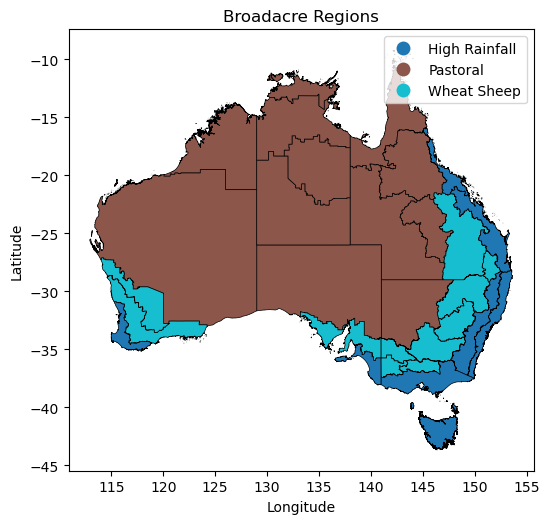

In [22]:
broadacre_gdf.plot(
    figsize=[6, 6],
    column='zone',
    legend=True,
    linewidth=0.5,
    edgecolor='black',
)
plt.title('Broadacre Regions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [23]:
wheatbelt_gdf = broadacre_gdf[broadacre_gdf.zone == 'Wheat Sheep']

In [26]:
wheatbelt = wheatbelt_gdf.dissolve()
wheatbelt = wheatbelt.drop(columns=['aagis', 'class', 'name'])

In [27]:
wheatbelt

,geometry,zone
0,"MULTIPOLYGON (((119.29102 -34.50538, 119.28886...",Wheat Sheep


In [ ]:
#wheatbelt.to_file('wheatbelt.shp')

In [29]:
wheatbelt_region = regionmask.from_geopandas(
    wheatbelt,
    names="zone",
    name="wheatbelt"
)

In [30]:
wheatbelt_region

<regionmask.Regions 'wheatbelt'>
overlap:  None

Regions:
0 r0 Wheat Sheep

[1 regions]

## Spatial selection and aggregation

In [35]:
mask = wheatbelt_region.mask_3D(da)
mask = mask.squeeze()

In [39]:
da_wheatbelt = da.where(mask)

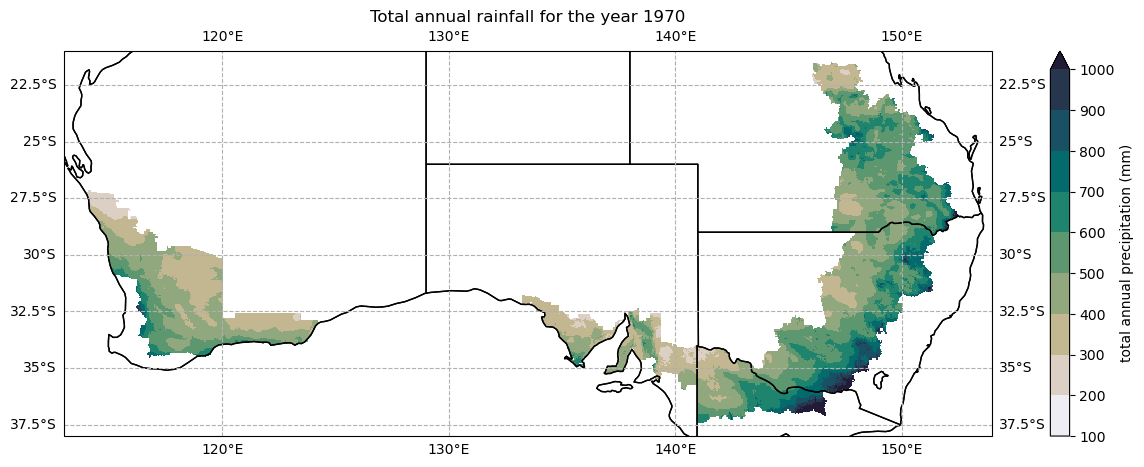

In [65]:
fig = plt.figure(figsize=[15, 5])
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    
da_wheatbelt.isel(time=10).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    levels=[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    extend='max',
    cbar_kwargs={'label': 'total annual precipitation (mm)'},
)
ax.coastlines()
ax.add_feature(cartopy.feature.STATES)
ax.gridlines(linestyle="--", draw_labels=True)
ax.set_extent([113, 154, -38, -21], crs=ccrs.PlateCarree())
ax.set_title('Total annual rainfall for the year 1970')
plt.show()

In [51]:
weights = np.cos(np.deg2rad(da['lat']))
da_spatial_mean = da_wheatbelt.weighted(weights).mean(dim=("lat", "lon"))

In [59]:
df_spatial_mean = da_spatial_mean.to_pandas()
df_spatial_mean.index = df_spatial_mean.index.year

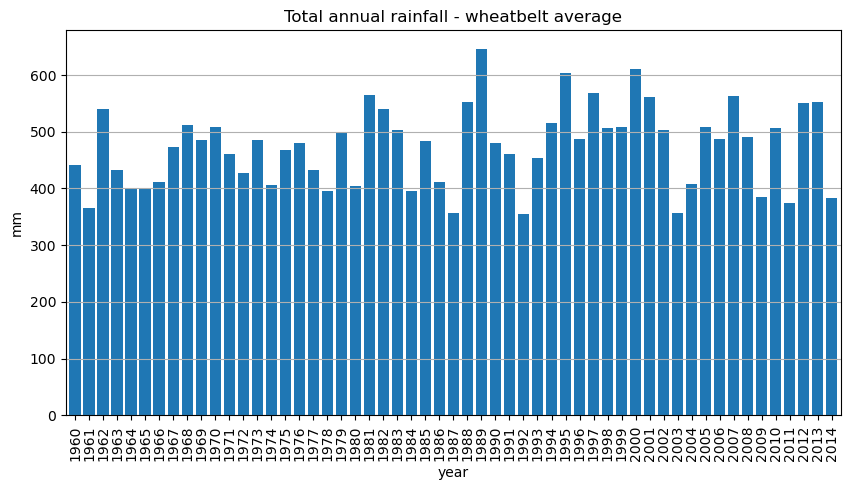

In [64]:
df_spatial_mean.plot.bar(figsize=[10, 5], width=0.8)
plt.ylabel('mm')
plt.xlabel('year')
plt.title('Total annual rainfall - wheatbelt average')
plt.grid(axis='y')
plt.show()